In [83]:
import pandas as pd
import plotly.express as px
from sklearn.linear_model import LinearRegression
import numpy as np
import seaborn as sns

In [ ]:
data =  pd.read_csv("credit_card_transactions.csv")
print(data.head())

In [ ]:
df1=data.copy()
df1 = df1.sample(int(len(data)*.5))
df1.columns


Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode'],
      dtype='object')

In [ ]:
def data_wrangling(data):
    df = data.copy()
    df['dob'] = pd.to_datetime(df1['dob'])
    df['trans_date_trans_time'] = pd.to_datetime(df1['trans_date_trans_time'])
    df['cc_num'] = df['cc_num'].astype(int)
    df1['street'] = df1['street'].astype(str)
    df1['merchant']= df1['merchant'].astype(str)
    return df

df = data_wrangling(df1)
print(len(df))
df.columns

648337


Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode'],
      dtype='object')

Text(0.5, 1.0, 'Sea Boarn Data Imbalance')

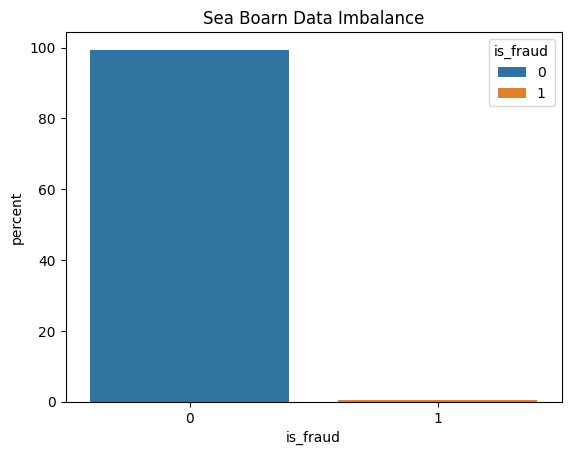

In [ ]:
import seaborn as sns
fig = sns.countplot(x='is_fraud', data=df,  hue="is_fraud", stat="percent",)
fig.set_title("Sea Boarn Data Imbalance")

## Method 1 : Random Undersampling:

Text(0.5, 1.0, 'Post Undersample data')

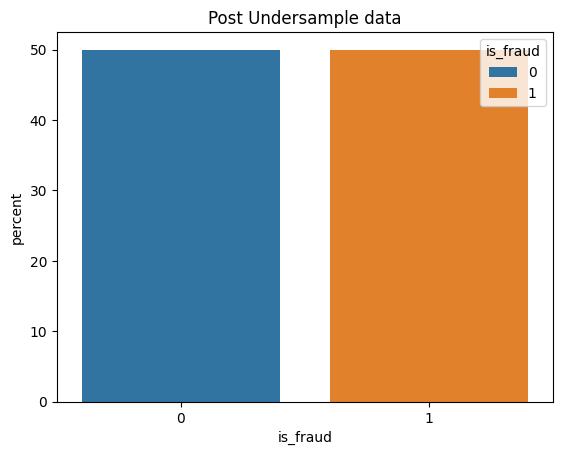

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
X = df1.drop(columns="is_fraud")
y = df1["is_fraud"]
rus = RandomUnderSampler(replacement=True)

X_res, y_res = rus.fit_resample(X, y)
#fig = sns.countplot(x='is_fraud', data=y_res,  hue="is_fraud", stat="percent",)
#fig.set_title("Sea Boarn Data Imbalance")
under_samp_df = X_res
under_samp_df['is_fraud'] =  y_res
fig = sns.countplot(x='is_fraud', data=under_samp_df,  hue="is_fraud", stat="percent",)
fig.set_title("Post Undersample data")

Random Undersampeling is one of the comman method to address the class imbalance in calssification problem. In highly Imbalance data set such as in our case credit <br>card Fraud transaction, non fraud transaction surpass the fraud transaction. <br>

Random undersampling mitigate this impalance by removing observasation untill it is more balanced distribution is achived. The main advantage is that fast to implement and computationaly efficient.<br>

However, with this simplicity there come some drawback as well. As it decrease the large protion of majority class, the model lose the potential to capture information pattern of major class. Which ultimatly lead to less generalization of model.<br>

## Method 2 : Random Oversampling:

Text(0.5, 1.0, 'Post Oversample data')

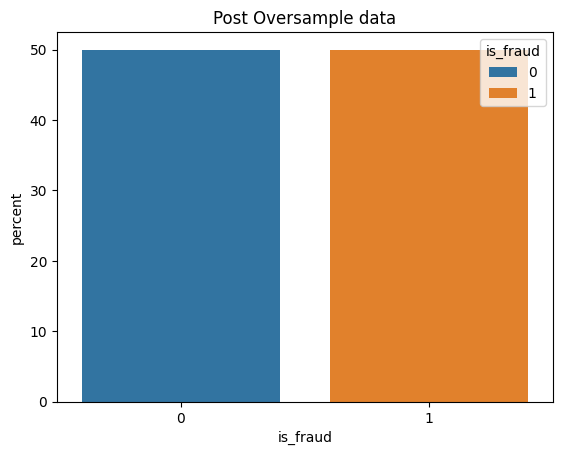

In [ ]:
from imblearn.over_sampling import RandomOverSampler
over_sampler = RandomOverSampler()
over_X, over_y = over_sampler.fit_resample(X,y)
over_df = over_X
over_df['is_fraud'] = over_y
fig = sns.countplot(x='is_fraud', data=over_df,  hue="is_fraud", stat="percent",)
fig.set_title("Post Oversample data")

Random Oversampling is an another comman process oppose to undersampling method,<br> where minority classs data is duplicated till the it balanced with majority <br>class data.<br>

Unlike Undesampling where there is chance of dicarding the informative patter, in <br>oversmapling such patterns are protected. <br>

However due to duplication of data model develope with this there as  a chance of <br>overfitting.<br>

## Method 3: SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
X_ = X.copy()
y_ = y.copy()
X_['hour'] = pd.to_datetime(X['trans_date_trans_time']).dt.hour
X_['day'] = pd.to_datetime(X['trans_date_trans_time']).dt.day
X_['month'] = pd.to_datetime(X['trans_date_trans_time']).dt.month

X_['d_hour'] = pd.to_datetime(X['dob']).dt.hour
X_['d_day'] = pd.to_datetime(X['dob']).dt.day
X_['d_month'] = pd.to_datetime(X['dob']).dt.month
X_['category'] = X_['category'].astype(str)
X_['trans_num'] = X_['trans_num'].astype(str)
## M = 0 F = 1
X_['gender'] = np.where(X_['gender']=="F",1,0)
X_ = X_.drop(columns=['dob','trans_date_trans_time','merch_zipcode','trans_num','merchant','category', 'first', 'last', 'street', 'city', 'state', 'job'])

In [ ]:
smote_ = SMOTE(random_state=50)
smote_X, smote_y = smote_.fit_resample(X_,y_)
smote_df = smote_X
smote_df['is_fraud'] = smote_y

Text(0.5, 1.0, 'Balanced Data Post Smoth')

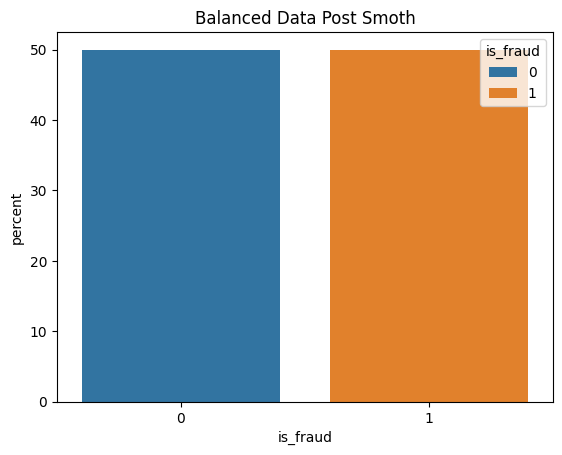

In [ ]:
fig = sns.countplot(x='is_fraud', data=smote_df,  hue="is_fraud", stat="percent",)
fig.set_title("Balanced Data Post Smoth")

Now that we have balanced the data with SMOTE. Lets know how it balance the data<br>
as:<br>
> S  Synthetic <br>
> M  Minority <br>
> O  Over-sampling <br>
> T  Technique <br>

As per the name suggest that it create some synthetic sample to over sample the <br>minority class.  By not duplicating the data this method over come the <br>overfitting process unlike in Random Over Sampling.<br>

This uses the interpolation method between existing data and neareast neighbors.